In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Загрузка и первичный осмотр данных

In [85]:
df = pd.read_csv('../data/raw/TZ.csv')
df.head(5)

,ID,ID_клиента,фамилия,кредитный_рейтинг,город,пол,возраст,стаж_в_банке,баланс_депозита,число_продуктов,есть_кредитка,активный_клиент,оценочная_зарплата,ушел_из_банка
0,0,15709511.0,Тестов55,754.0,Астана,Male,40.0,8.0,102954.68,2.0,1.0,1.0,149238.35,0.0
1,1,15592761.0,Тестов539,579.0,Алматы,Female,28.0,1.0,NaN,2.0,1.0,0.0,64869.32,0.0
2,2,15579914.0,Тестов275,744.0,Алматы,Female,56.0,5.0,NaN,1.0,1.0,0.0,158816.03,1.0
3,3,15669611.0,Есенгельдиев,697.0,Алматы,Male,29.0,2.0,NaN,2.0,1.0,0.0,55775.72,0.0
4,4,15761775.0,Тестов451,628.0,Алматы,Female,22.0,9.0,NaN,2.0,1.0,0.0,49653.39,0.0


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15000 non-null  int64  
 1   ID_клиента          15000 non-null  float64
 2   фамилия             15000 non-null  str    
 3   кредитный_рейтинг   15000 non-null  float64
 4   город               15000 non-null  str    
 5   пол                 15000 non-null  str    
 6   возраст             15000 non-null  float64
 7   стаж_в_банке        15000 non-null  float64
 8   баланс_депозита     5316 non-null   float64
 9   число_продуктов     15000 non-null  float64
 10  есть_кредитка       15000 non-null  float64
 11  активный_клиент     15000 non-null  float64
 12  оценочная_зарплата  15000 non-null  float64
 13  ушел_из_банка       15000 non-null  float64
dtypes: float64(10), int64(1), str(3)
memory usage: 1.6 MB


## 1.1 Анализ пропущенных значений

Единственный признак с пропусками — `баланс_депозита` (9684 пропуска, 64.6%).
Характер пропусков — **MNAR** (Missing Not At Random): отсутствие значения
означает, что у клиента нет депозита в банке, а не ошибку сбора данных.

**Гипотеза:** наличие/отсутствие депозита связано с вероятностью оттока.

In [87]:
df['депозит_отсутствует'] = df['баланс_депозита'].isna().astype(int)

In [88]:
churn_by_deposit = df.groupby('депозит_отсутствует')['ушел_из_банка'].agg(['mean', 'count'])
churn_by_deposit.index = ['Есть депозит', 'Нет депозита']
churn_by_deposit.columns = ['Доля оттока', 'Количество']
churn_by_deposit['Доля оттока'] = churn_by_deposit['Доля оттока'].round(3)
print(churn_by_deposit)

              Доля оттока  Количество
Есть депозит        0.288        5316
Нет депозита        0.158        9684


In [89]:
contingency_table = pd.crosstab(df['депозит_отсутствует'], df['ушел_из_банка'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nХи-квадрат: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Вывод: {'Связь ЕСТЬ (p < 0.05)' if p_value < 0.05 else 'Связи НЕТ (p >= 0.05)'}")



Хи-квадрат: 358.2931
P-value: 0.0000
Вывод: Связь ЕСТЬ (p < 0.05)


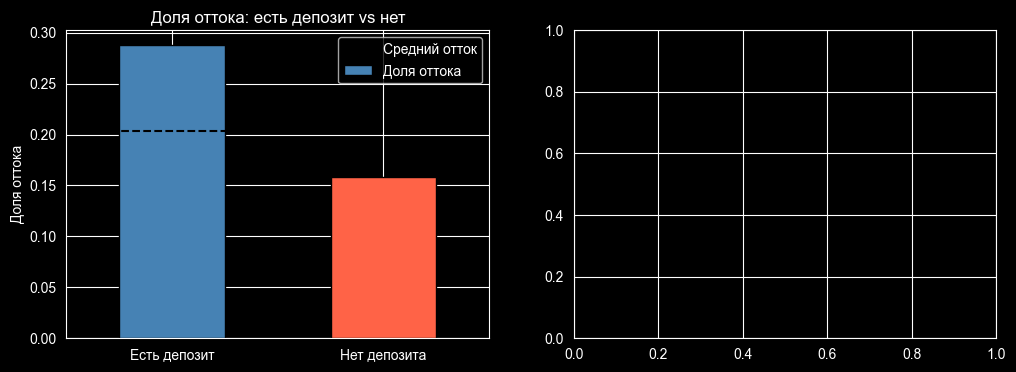

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Доля оттока по наличию депозита
churn_by_deposit['Доля оттока'].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0].set_title('Доля оттока: есть депозит vs нет')
axes[0].set_ylabel('Доля оттока')
axes[0].set_xticklabels(['Есть депозит', 'Нет депозита'], rotation=0)
axes[0].axhline(df['ушел_из_банка'].mean(), color='black', linestyle='--', label='Средний отток')
axes[0].legend()


**Вывод:** χ² = 358.29, p-value < 0.001 — связь статистически значима.
Доля оттока среди клиентов с депозитом (28.8%) вдвое выше, чем без него (15.8%).

> ⚠️ Неожиданный результат: клиенты *с* депозитом уходят чаще.
> Возможная причина: наличие депозита может коррелировать с возрастом или
> уровнем баланса — проверим это в разделе feature importance.

**Решение:** создать бинарный признак `есть_депозит` и заполнить пропуски нулём.
Простое заполнение медианой недопустимо — оно уничтожило бы информацию
о принципиально разных группах клиентов.

---
## 1.2 Обработка пропущенных значений

In [91]:
# Создаём флаг наличия депозита до заполнения пропусков
df['есть_депозит'] = df['баланс_депозита'].notna().astype(int)

# Заполняем пропуски нулём
df['баланс_депозита'] = df['баланс_депозита'].fillna(0)

print("Пропуски после обработки:")
print(df.isnull().sum())
print(f"\nРаспределение нового признака 'есть_депозит':")
print(df['есть_депозит'].value_counts())

Пропуски после обработки:
ID                     0
ID_клиента             0
фамилия                0
кредитный_рейтинг      0
город                  0
пол                    0
возраст                0
стаж_в_банке           0
баланс_депозита        0
число_продуктов        0
есть_кредитка          0
активный_клиент        0
оценочная_зарплата     0
ушел_из_банка          0
депозит_отсутствует    0
есть_депозит           0
dtype: int64

Распределение нового признака 'есть_депозит':
есть_депозит
0    9684
1    5316
Name: count, dtype: int64


**Результат:** пропуски устранены, добавлен признак `есть_депозит` (1 — есть депозит, 0 — нет).
Итоговый датасет: 15 000 строк, пропущенных значений нет.

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   15000 non-null  int64  
 1   ID_клиента           15000 non-null  float64
 2   фамилия              15000 non-null  str    
 3   кредитный_рейтинг    15000 non-null  float64
 4   город                15000 non-null  str    
 5   пол                  15000 non-null  str    
 6   возраст              15000 non-null  float64
 7   стаж_в_банке         15000 non-null  float64
 8   баланс_депозита      15000 non-null  float64
 9   число_продуктов      15000 non-null  float64
 10  есть_кредитка        15000 non-null  float64
 11  активный_клиент      15000 non-null  float64
 12  оценочная_зарплата   15000 non-null  float64
 13  ушел_из_банка        15000 non-null  float64
 14  депозит_отсутствует  15000 non-null  int64  
 15  есть_депозит         15000 non-null  int64  
dt

---
## 1.3 Удаление нерелевантных признаков

Признаки `ID`, `ID_клиента`, `фамилия` не несут предсказательной силы —
это технические идентификаторы. Также удаляем `депозит_отсутствует` как
дублирующий признак (инверсия `есть_депозит`).

In [93]:
cols_to_drop = ['ID', 'ID_клиента', 'фамилия', 'депозит_отсутствует']
df = df.drop(columns=cols_to_drop)

print(f"Признаков после очистки: {df.shape[1]}")
print(df.dtypes)

Признаков после очистки: 12
кредитный_рейтинг     float64
город                     str
пол                       str
возраст               float64
стаж_в_банке          float64
баланс_депозита       float64
число_продуктов       float64
есть_кредитка         float64
активный_клиент       float64
оценочная_зарплата    float64
ушел_из_банка         float64
есть_депозит            int64
dtype: object


**Результат:** удалено 4 нерелевантных признака.
Итоговый датасет: **15 000 строк, 12 признаков** (11 входных + 1 целевая переменная).

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   кредитный_рейтинг   15000 non-null  float64
 1   город               15000 non-null  str    
 2   пол                 15000 non-null  str    
 3   возраст             15000 non-null  float64
 4   стаж_в_банке        15000 non-null  float64
 5   баланс_депозита     15000 non-null  float64
 6   число_продуктов     15000 non-null  float64
 7   есть_кредитка       15000 non-null  float64
 8   активный_клиент     15000 non-null  float64
 9   оценочная_зарплата  15000 non-null  float64
 10  ушел_из_банка       15000 non-null  float64
 11  есть_депозит        15000 non-null  int64  
dtypes: float64(9), int64(1), str(2)
memory usage: 1.4 MB


---
# 2. Разведочный анализ данных (EDA)

Цель раздела — понять распределение признаков, выявить аномалии и выбросы,
оценить связь каждого признака с целевой переменной.

Структура раздела:
- 2.1 Анализ целевой переменной (дисбаланс классов)
- 2.2 Числовые признаки — распределения и выбросы
- 2.3 Категориальные признаки — город, пол
- 2.4 Корреляционный анализ
- 2.5 Выводы по EDA

## 2.1 Анализ целевой переменной

Прежде чем анализировать признаки, оценим баланс классов —
это напрямую влияет на выбор метрик и стратегию обучения модели.

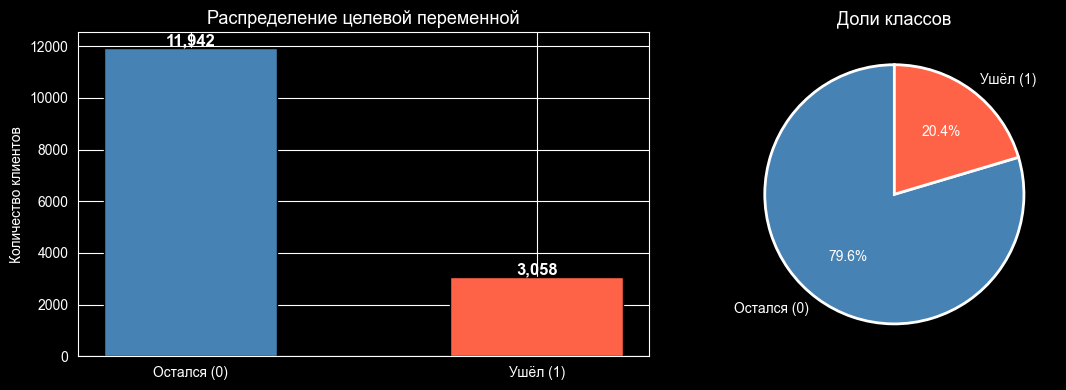

Класс 0 (остался): 11,942 (79.6%)
Класс 1 (ушёл):    3,058 (20.4%)
Соотношение классов: 1:3.9


In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Абсолютные значения
counts = df['ушел_из_банка'].value_counts()
bars = axes[0].bar(['Остался (0)', 'Ушёл (1)'], counts.values,
                   color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Распределение целевой переменной', fontsize=13)
axes[0].set_ylabel('Количество клиентов')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 100,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Доли в процентах
shares = df['ушел_из_банка'].value_counts(normalize=True) * 100
axes[1].pie(shares.values, labels=['Остался (0)', 'Ушёл (1)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Доли классов', fontsize=13)

plt.tight_layout()
plt.savefig('graphs/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Класс 0 (остался): {counts[0]:,} ({shares[0]:.1f}%)")
print(f"Класс 1 (ушёл):    {counts[1]:,} ({shares[1]:.1f}%)")
print(f"Соотношение классов: 1:{counts[0]/counts[1]:.1f}")

**Результат:** классы несбалансированы — соотношение 1:3.9
(79.6% остались, 20.4% ушли).

**Последствия для моделирования:**
Accuracy как метрика непригодна — модель может предсказывать всегда класс 0
и получать 79.6% accuracy, ничему не научившись.
Будем ориентироваться на **ROC-AUC, F1, precision/recall**.
При обучении применим `class_weight='balanced'`.

## 2.2 Числовые признаки — распределения и связь с оттоком

Для каждого числового признака строим два графика:
- гистограмму распределения с разбивкой по классам
- boxplot для выявления выбросов и разницы медиан

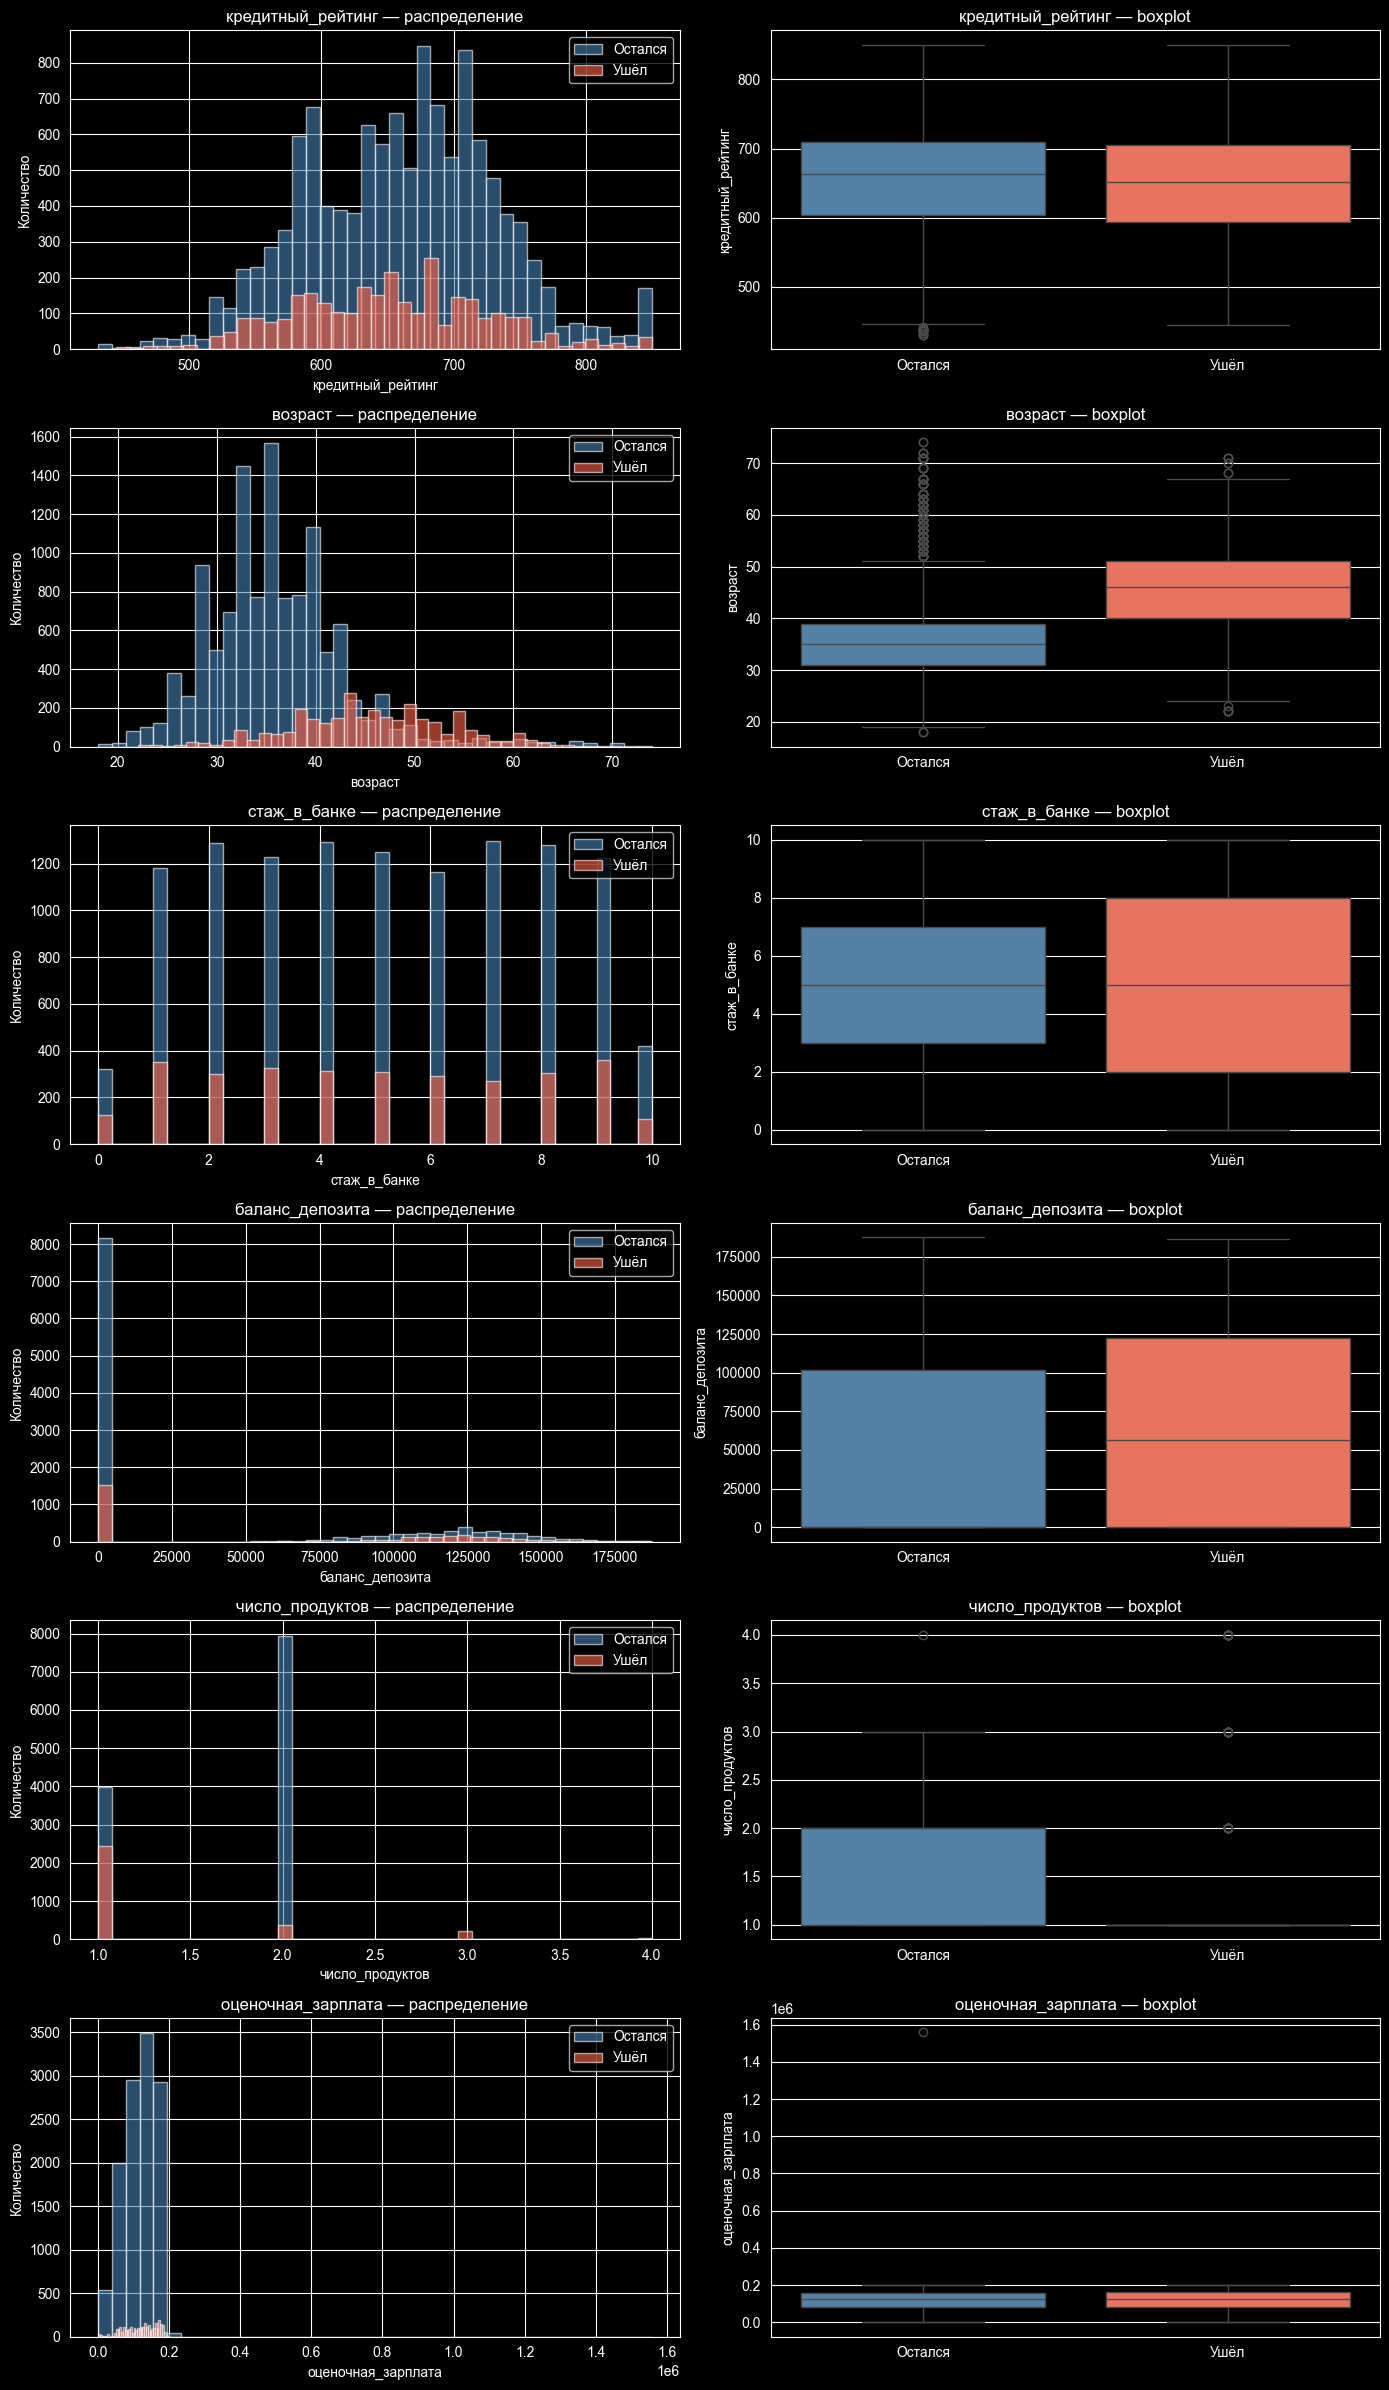

In [96]:
num_features = ['кредитный_рейтинг', 'возраст', 'стаж_в_банке',
                'баланс_депозита', 'число_продуктов', 'оценочная_зарплата']

fig, axes = plt.subplots(len(num_features), 2, figsize=(14, 4 * len(num_features)))

for i, col in enumerate(num_features):
    # Гистограмма с разбивкой по таргету
    for churn_val, label, color in zip([0, 1], ['Остался', 'Ушёл'], ['steelblue', 'tomato']):
        subset = df[df['ушел_из_банка'] == churn_val][col]
        axes[i, 0].hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[i, 0].set_title(f'{col} — распределение', fontsize=12)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Количество')
    axes[i, 0].legend()

    df_plot = df[[col, 'ушел_из_банка']].copy()
    df_plot['ушел_из_банка'] = df_plot['ушел_из_банка'].map({0: 'Остался', 1: 'Ушёл'})
    sns.boxplot(data=df_plot, x='ушел_из_банка', y=col,
                palette={'Остался': 'steelblue', 'Ушёл': 'tomato'},
                ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — boxplot', fontsize=12)
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.savefig('graphs/numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()

**Наблюдения:**

- `возраст` — **сильнейший сигнал оттока**. Ушедшие клиенты заметно старше:
  медиана ~45 лет против ~36 у оставшихся. Распределение ушедших смещено
  вправо и более равномерно в диапазоне 35–55 лет.

- `число_продуктов` — **очень важный признак**. Подавляющее большинство
  ушедших имеют 1 продукт, тогда как оставшиеся чаще имеют 2.
  Клиенты с 3–4 продуктами уходят крайне редко — высокая вовлечённость
  удерживает клиента.

- `баланс_депозита` — у ушедших медианный баланс выше (~100k против ~50k
  у оставшихся). В сочетании с флагом `есть_депозит` это подтверждает
  ранний инсайт: клиенты с крупным депозитом, но низкой активностью —
  группа риска.

- `кредитный_рейтинг` — распределения практически идентичны, медианы
  совпадают. Признак слабо различает классы, но оставляем —
  возможна нелинейная зависимость.

- `стаж_в_банке` — распределение равномерное у обоих классов,
  boxplot не показывает значимой разницы. Признак, вероятно,
  малоинформативен для модели.

- `оценочная_зарплата` — распределения полностью совпадают,
  разницы между классами нет. Признак скорее всего не будет
  важным для модели.

> ⚠️ Обнаружена потенциальная проблема в `оценочная_зарплата` и
> `баланс_депозита` — на гистограммах виден огромный пик у нуля
> и длинный хвост. Проверим на выбросы в следующем шаге.

### 2.2.1 Проверка на выбросы

In [97]:
Q1 = df[num_features].quantile(0.25)
Q3 = df[num_features].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_features] < (Q1 - 1.5 * IQR)) |
            (df[num_features] > (Q3 + 1.5 * IQR))).sum()

outliers_pct = (outliers / len(df) * 100).round(2)

outlier_df = pd.DataFrame({
    'Выбросов': outliers,
    '% от выборки': outliers_pct
})
print(outlier_df[outlier_df['Выбросов'] > 0].sort_values('Выбросов', ascending=False))

                    Выбросов  % от выборки
возраст                  417          2.78
число_продуктов           40          0.27
кредитный_рейтинг         15          0.10
оценочная_зарплата         1          0.01


**Результат проверки на выбросы:**

- `возраст` — 417 выбросов (2.78%). По boxplot это клиенты 65–75 лет.
  Это реальные клиенты, не ошибки данных — удалять не будем,
  дерево-based модели (CatBoost, XGBoost) устойчивы к таким выбросам.

- `число_продуктов` — 40 выбросов (0.27%). Клиенты с 3–4 продуктами.
  Редкие, но реальные случаи — оставляем.

- `кредитный_рейтинг` — 15 выбросов (0.10%). Единичные аномальные
  значения, не влияют на обучение.

- `оценочная_зарплата` — 1 выброс (0.01%). Пренебрежимо мало.

**Решение:** выбросы не удаляем и не трансформируем.
Их доля незначительна (максимум 2.78%), а выбранные модели
(CatBoost/XGBoost) изначально устойчивы к выбросам благодаря
построению на деревьях решений.

## 2.3 Категориальные признаки — город и пол

Оцениваем распределение категорий и их связь с оттоком.

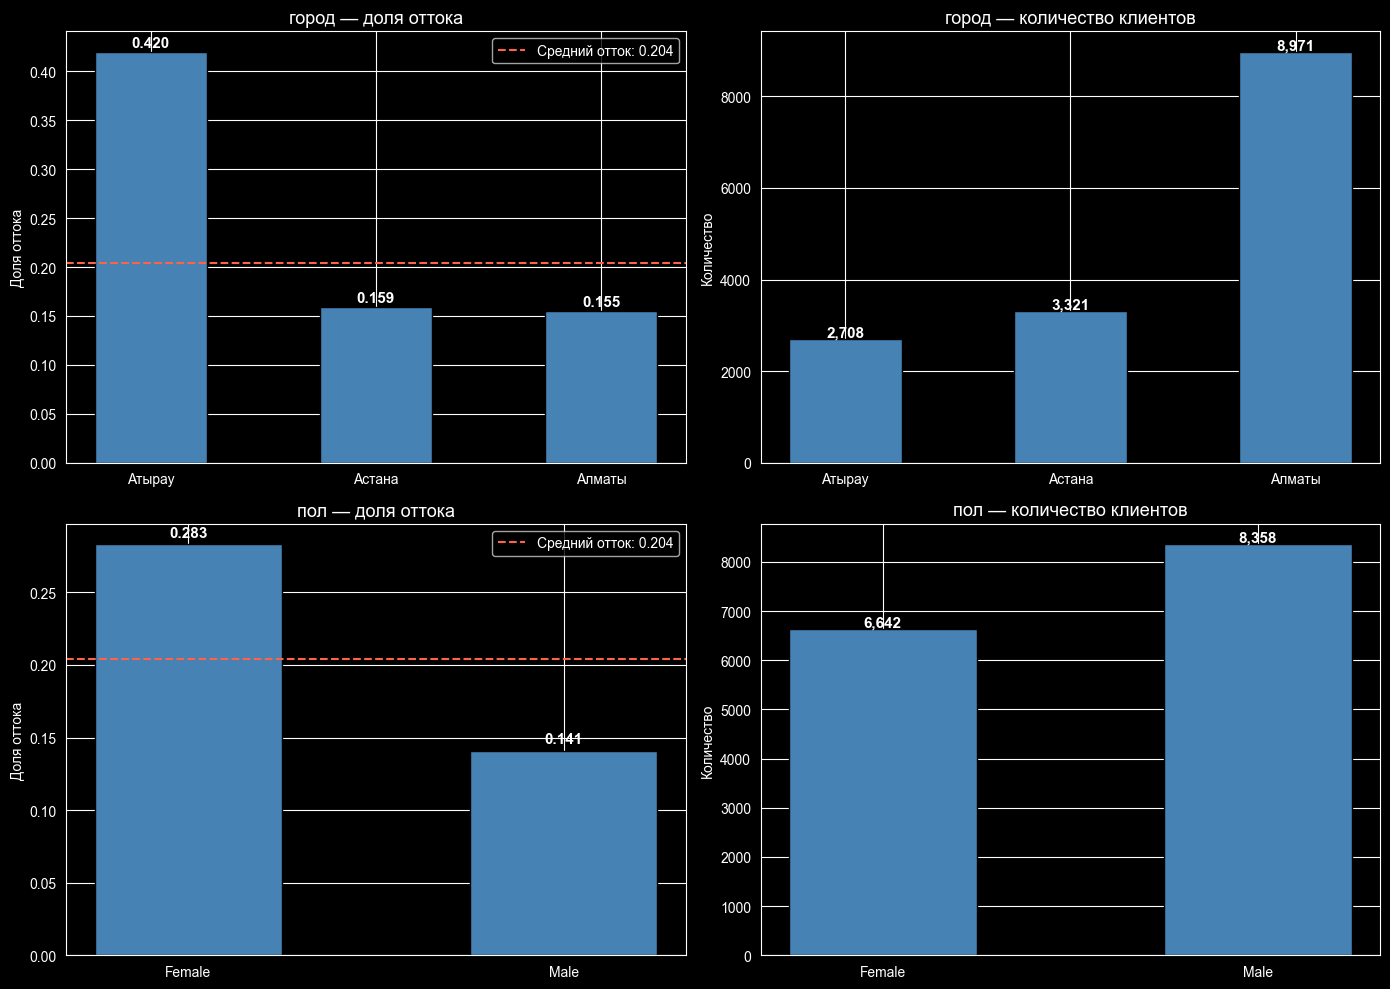


Признак: город
        Доля оттока  Количество
город                          
Алматы        0.155        8971
Астана        0.159        3321
Атырау        0.420        2708

Признак: пол
        Доля оттока  Количество
пол                            
Female        0.283        6642
Male          0.141        8358


In [98]:
# Чекнем пару графиков
cat_features = ['город', 'пол']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cat_features):
    # График 1 — доля оттока по категории
    churn_rate = df.groupby(col)['ушел_из_банка'].agg(['mean', 'count']).reset_index()
    churn_rate.columns = [col, 'доля_оттока', 'количество']
    churn_rate = churn_rate.sort_values('доля_оттока', ascending=False)

    bars = axes[i, 0].bar(churn_rate[col], churn_rate['доля_оттока'],
                          color='steelblue', edgecolor='black', width=0.5)
    axes[i, 0].axhline(df['ушел_из_банка'].mean(), color='tomato',
                       linestyle='--', label=f'Средний отток: {df["ушел_из_банка"].mean():.3f}')
    axes[i, 0].set_title(f'{col} — доля оттока', fontsize=13)
    axes[i, 0].set_ylabel('Доля оттока')
    axes[i, 0].legend()
    for bar, val in zip(bars, churn_rate['доля_оттока']):
        axes[i, 0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                        f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

    # График 2 — количество клиентов по категории
    axes[i, 1].bar(churn_rate[col], churn_rate['количество'],
                   color='steelblue', edgecolor='black', width=0.5)
    axes[i, 1].set_title(f'{col} — количество клиентов', fontsize=13)
    axes[i, 1].set_ylabel('Количество')
    for bar, val in zip(axes[i, 1].patches, churn_rate['количество']):
        axes[i, 1].text(bar.get_x() + bar.get_width()/2, val + 50,
                        f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Числовая сводка
for col in cat_features:
    print(f"\n{'='*40}")
    print(f"Признак: {col}")
    summary = df.groupby(col)['ушел_из_банка'].agg(['mean', 'count'])
    summary.columns = ['Доля оттока', 'Количество']
    summary['Доля оттока'] = summary['Доля оттока'].round(3)
    print(summary)

**Наблюдения:**

- `город` — **критически важный признак**. Атырау выбивается из общей картины:
  доля оттока 42.0% против 15.5–15.9% в Алматы и Астане — разница почти втрое.
  Это может указывать на региональную специфику (конкуренция, качество сервиса,
  экономические факторы). Признак однозначно войдёт в топ по важности.

- `пол` — **значимый признак**. Женщины уходят вдвое чаще мужчин (28.3% vs 14.1%).
  При этом женщин в выборке меньше (6,642 vs 8,358), что усиливает дисбаланс
  внутри класса 1.

> ⚠️ Атырау требует отдельного внимания при бизнес-интерпретации результатов —
> возможно, там другая клиентская база или конкурентная среда. Это стоит
> отметить в финальных выводах как направление для дополнительного исследования.

**Решение по кодированию:**
`город` и `пол` — низкокардинальные категориальные признаки (3 и 2 значения).
Применим One-Hot Encoding в разделе предобработки.

## 2.4 Корреляционный анализ

Оцениваем линейные связи между числовыми признаками и целевой переменной.
Также проверяем на мультиколлинеарность — сильно коррелирующие признаки
могут навредить линейным моделям.

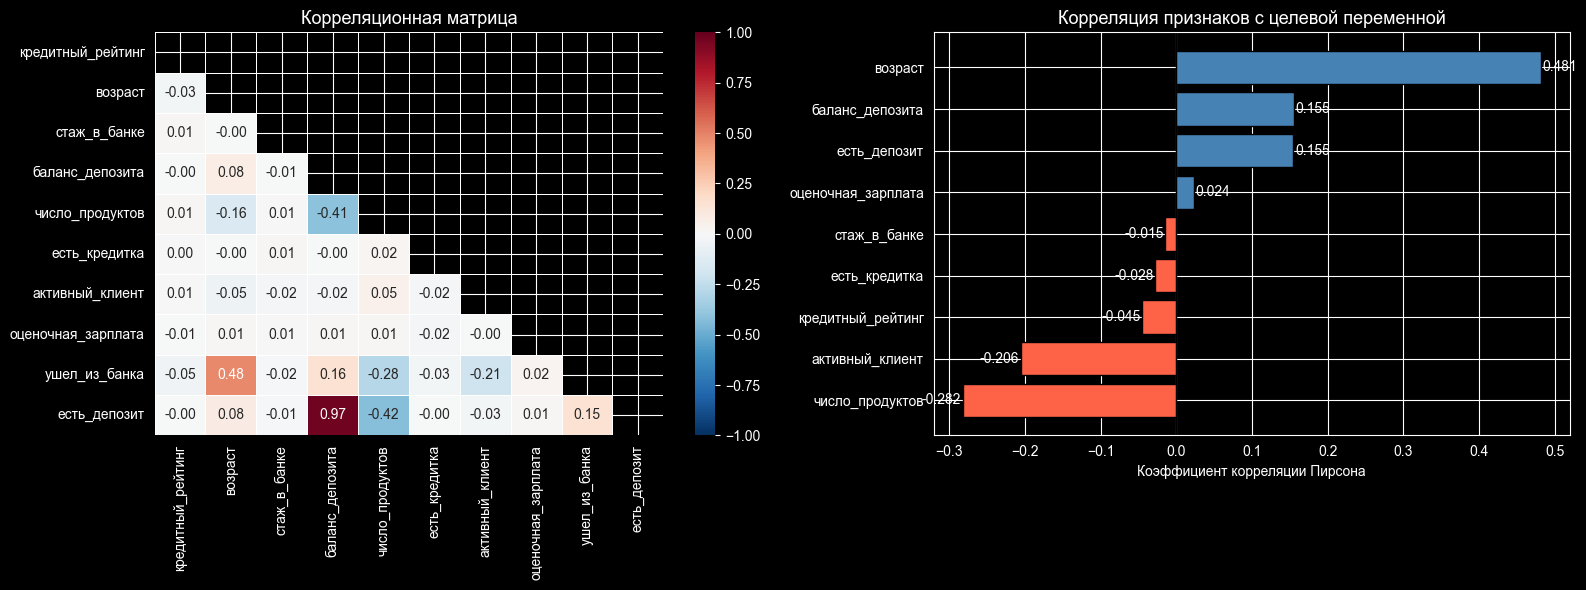

Корреляция с целевой переменной:
число_продуктов      -0.282
активный_клиент      -0.206
кредитный_рейтинг    -0.045
есть_кредитка        -0.028
стаж_в_банке         -0.015
оценочная_зарплата    0.024
есть_депозит          0.155
баланс_депозита       0.155
возраст               0.481


In [99]:
# Для корреляции берём только числовые признаки
num_df = df.select_dtypes(include='number')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — тепловая карта корреляций
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Корреляционная матрица', fontsize=13)

# График 2 — корреляция признаков с таргетом
target_corr = num_df.corr()['ушел_из_банка'].drop('ушел_из_банка').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Корреляция признаков с целевой переменной', fontsize=13)
axes[1].set_xlabel('Коэффициент корреляции Пирсона')
for i, val in enumerate(target_corr.values):
    axes[1].text(val + (0.002 if val >= 0 else -0.002), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('graphs/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

import numpy as np
print("Корреляция с целевой переменной:")
print(target_corr.round(3).to_string())

**Наблюдения:**

**Связь с целевой переменной:**
- `возраст` (+0.481) — strongest signal, самая высокая линейная корреляция.
  Чем старше клиент, тем выше вероятность ухода.
- `число_продуктов` (−0.282) — чем больше продуктов, тем ниже отток.
  Клиент с 1 продуктом — группа риска.
- `активный_клиент` (−0.206) — неактивные клиенты уходят заметно чаще.
- `есть_депозит` и `баланс_депозита` (+0.155) — подтверждают ранний инсайт:
  наличие депозита парадоксально коррелирует с уходом.
- `стаж_в_банке`, `есть_кредитка`, `оценочная_зарплата` — корреляция
  близка к нулю, признаки слабо информативны линейно, но могут быть
  полезны в нелинейных моделях.

**Мультиколлинеарность:**
- `баланс_депозита` и `есть_депозит` коррелируют между собой на уровне **0.97** —
  это очень высокая мультиколлинеарность. Для линейных моделей это проблема,
  однако для tree-based моделей (CatBoost, XGBoost) она некритична.
  Оба признака оставляем — они несут разную смысловую нагрузку
  (факт наличия депозита vs его размер).
- Остальные пары признаков корреляции ниже 0.5 — мультиколлинеарности нет.

> ℹ️ Корреляция Пирсона измеряет только **линейные** зависимости.
> Категориальные признаки `город` и `пол` здесь не учтены —
> их важность уже подтверждена в разделе 2.3.

## 2.5 Выводы по EDA

**Ключевые факторы оттока (топ признаков по силе сигнала):**

| Признак | Сигнал | Наблюдение |
|---|---|---|
| `возраст` | Сильный ↑ | Ушедшие клиенты старше (~45 vs ~36 лет) |
| `город` | Сильный ↑ | Атырау: отток 42% vs 15–16% в других городах |
| `число_продуктов` | Сильный ↓ | 1 продукт = группа риска |
| `активный_клиент` | Средний ↓ | Неактивные уходят вдвое чаще |
| `пол` | Средний ↑ | Женщины уходят вдвое чаще мужчин (28% vs 14%) |
| `есть_депозит` | Средний ↑ | Клиенты с депозитом уходят чаще |
| `баланс_депозита` | Средний ↑ | У ушедших медианный баланс выше |

**Решения принятые по итогам EDA:**
- Дисбаланс классов 1:3.9 — применим `class_weight='balanced'`
- Выбросы не удаляем — их доля мала, tree-based модели устойчивы
- Мультиколлинеарность `баланс_депозита` / `есть_депозит` (0.97) —
  некритична для выбранных моделей, оба признака сохраняем
- `стаж_в_банке`, `оценочная_зарплата` — слабый сигнал,
  но удалять не будем, позволим модели самой оценить важность через SHAP

**Следующий шаг:** предобработка данных — кодирование категориальных
признаков и масштабирование для линейных моделей.

In [100]:
print("Финальный датасет перед сохранением:")
print(df.dtypes)
print(f"\nРазмер: {df.shape}")
print(f"Пропуски: {df.isnull().sum().sum()}")

df.to_csv('../data/processed/churn_cleaned.csv', index=False)
print("\nДатасет сохранён в data/churn_cleaned.csv")

Финальный датасет перед сохранением:
кредитный_рейтинг     float64
город                     str
пол                       str
возраст               float64
стаж_в_банке          float64
баланс_депозита       float64
число_продуктов       float64
есть_кредитка         float64
активный_клиент       float64
оценочная_зарплата    float64
ушел_из_банка         float64
есть_депозит            int64
dtype: object

Размер: (15000, 12)
Пропуски: 0

Датасет сохранён в data/churn_cleaned.csv
